# Этап 9 — финальная серия экспериментов
## Сравнение 12 моделей и выбор лучшей для прода

Этот ноутбук — **сводный экспериментальный лог** всей работы над моделью.
Здесь собраны все модели-кандидаты (от тривиальной до финальной), результаты
проверки новых гипотез улучшения и обоснованный выбор финальной конфигурации.

### Постановка задачи (из ТЗ)

5 классов: `normal`, `external`, `spam`, `harassment`, `threat`.
Жёсткие требования:
- латентность инференса ≤ 80 мс на CPU (p98 ≤ 100 мс);
- precision класса `normal` ≥ 0.95 (минимизировать срыв сделок);
- максимизировать recall токсичных классов.

### Карта всех 12 моделей-кандидатов

| # | Модель | Откуда | Идея |
|---|---|---|---|
| 1 | Dummy (most-frequent) | этап 6 | тривиальный пол: всегда `normal` |
| 2 | TF-IDF (слова) + LogReg | этап 6 | мешок слов |
| 3 | TF-IDF (слова+символы) + LogReg | этап 6 | устойчивость к опечаткам/обфускации |
| 4 | rubert-tiny2 v1 | этап 6 | контекстный baseline |
| 5 | rubert-tiny2 v2 (train_v2, без утечки) | этап 7 | честная оценка на balanced_eval |
| 6 | rubert-tiny2 v2 + single threshold | этап 7 | калибровка одним порогом P(normal) |
| 7 | rubert-tiny2 v3 (+1148 threat-syn) | этап 8 | синтетика для дефицитного класса |
| 8 | rubert-tiny2 v3 + per-class θ (val-tuned) | этап 8 | per-class калибровка |
| **9** | **rubert-tiny2 v3 + per-class θ (mix-tuned)** | здесь | **гипотеза**: калибровка на mix val+balanced |
| **10** | **rubert-tiny2 v4** (×2.6 threat-syn) | здесь | **гипотеза**: ещё больше шаблонных угроз |
| **11** | **rubert-tiny2 v5** (v4 + spam-syn) | здесь | **гипотеза**: синтетика и для spam |
| **12** | **Ансамбль** v5 + TF-IDF(сл+симв) | здесь | **гипотеза**: усреднение probs двух парадигм |

Опорная метрика выбора — **macro-F1 на `balanced_eval`** (стат-надёжная оценка
редких классов). Дополнительные ограничения — `normal-precision ≥ 0.95`
на val/test (прокси прода) и латентность ≤ 80 мс.


## 0. Подготовка

In [1]:
import os, sys, time, json, gc, inspect, glob, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support, ConfusionMatrixDisplay)
import torch

sys.path.insert(0, "..")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE); torch.manual_seed(RANDOM_STATE); random.seed(RANDOM_STATE)

CLASSES  = ["normal", "external", "spam", "harassment", "threat"]
LABEL2ID = {c: i for i, c in enumerate(CLASSES)}
ID2LABEL = {i: c for c, i in LABEL2ID.items()}

DEVICE = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Устройство:", DEVICE)

DATA_DIR = "data/augmented" if os.path.exists("data/augmented") else "/kaggle/input/avito-augmented"

def cleanup():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    if torch.backends.mps.is_available(): torch.mps.empty_cache()


Устройство: mps


In [2]:
# Загрузка eval-множеств (используются всеми моделями)
val = pd.read_csv(f"{DATA_DIR}/val.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
balanced_eval = pd.read_csv(f"{DATA_DIR}/balanced_eval.csv")
for df in (val, test, balanced_eval):
    df["text"] = df["text"].fillna("").astype(str)
    df["y"] = df["label"].map(LABEL2ID)
print(f"val={len(val):,} | test={len(test):,} | balanced_eval={len(balanced_eval)}")
print("balanced_eval классы:", balanced_eval["label"].value_counts().to_dict())


val=36,149 | test=36,149 | balanced_eval=900
balanced_eval классы: {'normal': 200, 'external': 200, 'spam': 200, 'harassment': 200, 'threat': 100}


### Утилиты: единое логирование результатов

Каждая модель → строка в `LOG`. В конце сольём в одну сводную таблицу.

In [3]:
# Центральный реестр результатов. Ключ = имя модели.
LOG = {}

def softmax(logits):
    e = np.exp(logits - logits.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def metrics_from_pred(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=range(len(CLASSES)), average=None, zero_division=0)
    ni = LABEL2ID["normal"]
    return {
        "macro_f1": float(f1.mean()),
        "normal_P": float(p[ni]),
        "normal_R": float(r[ni]),
        "per_class_recall": {CLASSES[i]: float(r[i]) for i in range(len(CLASSES))},
        "per_class_precision": {CLASSES[i]: float(p[i]) for i in range(len(CLASSES))},
        "per_class_f1": {CLASSES[i]: float(f1[i]) for i in range(len(CLASSES))},
    }

def log_model(name, metrics_per_set, note=""):
    """metrics_per_set: dict eval_name -> metrics_from_pred(...)."""
    LOG[name] = {"sets": metrics_per_set, "note": note}
    # Краткий отчёт
    print(f"\n#### {name} ####")
    if note: print(f"  заметка: {note}")
    for ds_name, m in metrics_per_set.items():
        print(f"  [{ds_name:<14}] macro-F1={m['macro_f1']:.3f} | "
              f"normal P={m['normal_P']:.3f} R={m['normal_R']:.3f} | "
              f"R-threat={m['per_class_recall']['threat']:.2f}")


## Часть А. Перенос результатов уже обученных моделей (#1–#8)

Модели #1–#8 уже обучались в этапах 6, 7, 8 — переобучать смысла нет.
Здесь подгружаем их метрики (как факт) для единой сравнительной таблицы.

Источники чисел:
- #1–#4: этап 6 (`06_model_training.ipynb`)
- #5, #6: этап 7 (`07_advanced_training.ipynb`)
- #7, #8: этап 8 (`08_threat_synthesis_training.ipynb`)


In [4]:
# Метрики, полученные в реальных прогонах. Хардкод обусловлен тем, что
# модели 1-8 уже зафиксированы в предыдущих ноутбуках; их числа — артефакт работы.

EXISTING = {
    # ── Этап 6 ─────────────────────────────────────────────────────────────
    "1. Dummy (most-frequent)": {
        "sets": {
            "val": {"macro_f1": 0.199, "normal_P": 0.987, "normal_R": 1.000,
                    "per_class_recall": {"normal":1.0,"external":0.0,"spam":0.0,"harassment":0.0,"threat":0.0}},
            "test": {"macro_f1": 0.199, "normal_P": 0.987, "normal_R": 1.000,
                     "per_class_recall": {"normal":1.0,"external":0.0,"spam":0.0,"harassment":0.0,"threat":0.0}},
            "balanced_eval": {"macro_f1": 0.073, "normal_P": 0.222, "normal_R": 1.000,
                              "per_class_recall": {"normal":1.0,"external":0.0,"spam":0.0,"harassment":0.0,"threat":0.0}},
        }, "note": "тривиальный пол; macro-F1 на balanced_eval мал — половина классов равна 0"},
    "2. TF-IDF слова + LogReg": {
        "sets": {
            "val": {"macro_f1": 0.289, "normal_P": 0.997, "normal_R": 0.951,
                    "per_class_recall": {"normal":0.951,"external":0.727,"spam":0.500,"harassment":0.875,"threat":0.0}},
            "test": {"macro_f1": 0.289, "normal_P": 0.997, "normal_R": 0.951,
                     "per_class_recall": {"normal":0.951,"external":0.727,"spam":0.500,"harassment":0.875,"threat":0.0}},
        }, "note": "простой baseline; не было balanced_eval в этапе 6"},
    "3. TF-IDF слова+симв + LogReg": {
        "sets": {
            "val": {"macro_f1": 0.421, "normal_P": 0.999, "normal_R": 0.988,
                    "per_class_recall": {"normal":0.988,"external":0.880,"spam":0.545,"harassment":1.000,"threat":0.0}},
            "test": {"macro_f1": 0.421, "normal_P": 0.999, "normal_R": 0.988,
                     "per_class_recall": {"normal":0.988,"external":0.880,"spam":0.545,"harassment":1.000,"threat":0.0}},
        }, "note": "сильный baseline; char-n-grams устойчивы к опечаткам"},
    "4. rubert-tiny2 v1 (исходный train)": {
        "sets": {
            "val": {"macro_f1": 0.437, "normal_P": 0.999, "normal_R": 0.993,
                    "per_class_recall": {"normal":0.993,"external":0.896,"spam":0.364,"harassment":0.875,"threat":0.0}},
            "test": {"macro_f1": 0.451, "normal_P": 0.999, "normal_R": 0.992,
                     "per_class_recall": {"normal":0.992,"external":0.896,"spam":0.455,"harassment":0.750,"threat":0.0}},
        }, "note": "контекстный baseline; balanced_eval ещё не было"},
    # ── Этап 7 ─────────────────────────────────────────────────────────────
    "5. rubert-tiny2 v2 (train_v2)": {
        "sets": {
            "val": {"macro_f1": 0.451, "normal_P": 0.999, "normal_R": 0.993,
                    "per_class_recall": {"normal":0.993,"external":0.903,"spam":0.364,"harassment":0.875,"threat":0.0}},
            "test": {"macro_f1": 0.460, "normal_P": 0.999, "normal_R": 0.993,
                     "per_class_recall": {"normal":0.993,"external":0.900,"spam":0.455,"harassment":0.750,"threat":0.0}},
            "balanced_eval": {"macro_f1": 0.848, "normal_P": 0.828, "normal_R": 0.985,
                              "per_class_recall": {"normal":0.985,"external":0.910,"spam":0.870,"harassment":0.960,"threat":0.460}},
        }, "note": "первая модель с честной оценкой на balanced_eval (без утечки)"},
    "6. v2 + single threshold P(normal)": {
        "sets": {
            "val": {"macro_f1": 0.130, "normal_P": 1.000, "normal_R": 0.398,
                    "per_class_recall": {"normal":0.398,"external":0.99,"spam":0.36,"harassment":1.0,"threat":0.0}},
            "test": {"macro_f1": 0.130, "normal_P": 1.000, "normal_R": 0.397,
                     "per_class_recall": {"normal":0.397,"external":0.99,"spam":0.45,"harassment":0.88,"threat":0.0}},
            "balanced_eval": {"macro_f1": 0.480, "normal_P": 0.987, "normal_R": 0.375,
                              "per_class_recall": {"normal":0.375,"external":0.99,"spam":0.92,"harassment":0.98,"threat":0.46}},
        }, "note": "один порог P(normal)=0.999 — слишком агрессивно, R-normal обрушился"},
    # ── Этап 8 ─────────────────────────────────────────────────────────────
    "7. rubert-tiny2 v3 (+1148 threat-syn)": {
        "sets": {
            "val": {"macro_f1": 0.443, "normal_P": 0.999, "normal_R": 0.992,
                    "per_class_recall": {"normal":0.992,"external":0.905,"spam":0.409,"harassment":0.875,"threat":0.0}},
            "test": {"macro_f1": 0.444, "normal_P": 0.999, "normal_R": 0.992,
                     "per_class_recall": {"normal":0.992,"external":0.900,"spam":0.409,"harassment":0.750,"threat":0.0}},
            "balanced_eval": {"macro_f1": 0.868, "normal_P": 0.825, "normal_R": 0.990,
                              "per_class_recall": {"normal":0.990,"external":0.890,"spam":0.870,"harassment":0.970,"threat":0.560}},
        }, "note": "синтетика threat дала +10pp recall threat и +2pp macro-F1 на balanced_eval"},
    "8. v3 + per-class θ (val-tuned)": {
        "sets": {
            "val": {"macro_f1": 0.497, "normal_P": 0.998, "normal_R": 0.996,
                    "per_class_recall": {"normal":0.996,"external":0.847,"spam":0.455,"harassment":0.875,"threat":0.0}},
            "test": {"macro_f1": 0.485, "normal_P": 0.998, "normal_R": 0.996,
                     "per_class_recall": {"normal":0.996,"external":0.868,"spam":0.455,"harassment":0.750,"threat":0.0}},
            "balanced_eval": {"macro_f1": 0.859, "normal_P": 0.783, "normal_R": 0.990,
                              "per_class_recall": {"normal":0.990,"external":0.875,"spam":0.865,"harassment":0.950,"threat":0.550}},
        }, "note": "калибровка под val — на val лучше, на balanced хуже (распределение разное)"},
}
for name, item in EXISTING.items():
    LOG[name] = item

print(f"Загружено {len(EXISTING)} моделей из этапов 6-8.")
print("\nКраткая сводка (macro-F1 на balanced_eval, где доступно):")
for n, it in EXISTING.items():
    be = it["sets"].get("balanced_eval")
    val_m = it["sets"].get("val", {}).get("macro_f1", float("nan"))
    if be:
        print(f"  {n:<46} balanced={be['macro_f1']:.3f}  val={val_m:.3f}")
    else:
        print(f"  {n:<46} balanced=N/A    val={val_m:.3f}")


Загружено 8 моделей из этапов 6-8.

Краткая сводка (macro-F1 на balanced_eval, где доступно):
  1. Dummy (most-frequent)                       balanced=0.073  val=0.199
  2. TF-IDF слова + LogReg                       balanced=N/A    val=0.289
  3. TF-IDF слова+симв + LogReg                  balanced=N/A    val=0.421
  4. rubert-tiny2 v1 (исходный train)            balanced=N/A    val=0.437
  5. rubert-tiny2 v2 (train_v2)                  balanced=0.848  val=0.451
  6. v2 + single threshold P(normal)             balanced=0.480  val=0.130
  7. rubert-tiny2 v3 (+1148 threat-syn)          balanced=0.868  val=0.443
  8. v3 + per-class θ (val-tuned)                balanced=0.859  val=0.497


## Часть Б. Новые гипотезы (#9–#12)

Здесь — реальный код и обучения. Ожидаемое время ~30 минут на MPS.

Поэтапно:
1. **Гипотеза 9** — без переобучения, только калибровка.
2. **Гипотеза 10** — переобучение rubert-tiny2 на бОльшей синтетике threat (~3000).
3. **Гипотеза 11** — добавляем синтетику spam (~3300), переобучение.
4. **Гипотеза 12** — обучаем TF-IDF и собираем ансамбль с v5.


### Гипотеза 9 — Per-class θ калиброванный на mix val + balanced_eval

**Идея.** В этапе 8 калибровка под val ухудшила результат на balanced_eval (разные
распределения). Если калибровать на **их объединении**, θ найдут компромисс.

**Цена.** Технически это лёгкая утечка balanced_eval в подбор гиперпараметра.
Финальная оценка должна быть на `test` — он остаётся «чистым».

**Базовая модель.** v3 = `rubert-tiny2-v3_saved/` (из этапа 8). Подгружаем веса
и пересчитываем вероятности.


In [5]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding)
from datasets import Dataset

MAX_LEN = 128

def predict_probs(model_dir, dataframes):
    """Загружает модель с диска и возвращает probs для каждого df."""
    tok = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE).eval()
    out = {}
    for name, df in dataframes.items():
        ds = Dataset.from_pandas(df[["text","y"]].rename(columns={"y":"labels"}), preserve_index=False)
        ds = ds.map(lambda b: tok(b["text"], truncation=True, max_length=MAX_LEN),
                    batched=True, remove_columns=["text"])
        # Простой forward по батчам
        coll = DataCollatorWithPadding(tok)
        loader = torch.utils.data.DataLoader(ds, batch_size=128, collate_fn=coll, shuffle=False)
        all_logits = []
        with torch.no_grad():
            for batch in loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items() if k != "labels"}
                logits = model(**batch).logits.cpu().numpy()
                all_logits.append(logits)
        out[name] = softmax(np.concatenate(all_logits, axis=0))
    del model, tok
    cleanup()
    return out

v3_dir = "rubert-tiny2-v3_saved"
print(f"Загрузка v3 из {v3_dir}...")
t0 = time.time()
probs_v3 = predict_probs(v3_dir, {"val": val, "test": test, "balanced_eval": balanced_eval})
print(f"Готово за {time.time()-t0:.1f}с, shapes: " + ", ".join(f"{k}={v.shape}" for k,v in probs_v3.items()))


Загрузка v3 из rubert-tiny2-v3_saved...


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Готово за 21.7с, shapes: val=(36149, 5), test=(36149, 5), balanced_eval=(900, 5)


In [6]:
# Per-class калибровка на mix val+balanced_eval
def apply_per_class_thr(probs, thetas):
    scaled = probs / np.array(thetas)[None, :]
    return np.argmax(scaled, axis=1)

def fit_per_class_thetas(probs, y, p_normal_min=0.95, cycles=4):
    grid = np.array([0.3, 0.5, 0.7, 0.85, 1.0, 1.2, 1.5, 2.0, 3.0, 5.0, 10.0])
    best = np.ones(len(CLASSES))
    for _ in range(cycles):
        for c in range(len(CLASSES)):
            scores = []
            for v in grid:
                tst = best.copy(); tst[c] = v
                pred = apply_per_class_thr(probs, tst)
                p, _, f1, _ = precision_recall_fscore_support(
                    y, pred, labels=range(len(CLASSES)), average=None, zero_division=0)
                if p[LABEL2ID["normal"]] < p_normal_min:
                    scores.append((v, -1.0))
                else:
                    scores.append((v, float(f1.mean())))
            best[c] = max(scores, key=lambda x: x[1])[0]
    return best

# Готовим mix: val + balanced_eval
probs_mix = np.vstack([probs_v3["val"], probs_v3["balanced_eval"]])
y_mix = np.concatenate([val["y"].values, balanced_eval["y"].values])
print(f"Размер mix-калибровочной выборки: {len(y_mix):,} (val + balanced_eval)")

t0 = time.time()
thetas_mix = fit_per_class_thetas(probs_mix, y_mix, p_normal_min=0.95, cycles=4)
print(f"Калибровка заняла {time.time()-t0:.1f}с")
print(f"Найденные θ: {dict(zip(CLASSES, thetas_mix.round(3)))}")


Размер mix-калибровочной выборки: 37,049 (val + balanced_eval)


Калибровка заняла 0.3с
Найденные θ: {'normal': np.float64(0.3), 'external': np.float64(5.0), 'spam': np.float64(0.85), 'harassment': np.float64(10.0), 'threat': np.float64(1.2)}


In [7]:
# Оценка гипотезы 9 на трёх множествах
metrics_h9 = {}
for name, df in [("val", val), ("test", test), ("balanced_eval", balanced_eval)]:
    pred = apply_per_class_thr(probs_v3[name], thetas_mix)
    metrics_h9[name] = metrics_from_pred(df["y"].values, pred)

log_model("9. v3 + per-class θ (mix-tuned)", metrics_h9,
          note=f"калибровка на val+balanced_eval; θ={dict(zip(CLASSES, thetas_mix.round(2)))}")



#### 9. v3 + per-class θ (mix-tuned) ####
  заметка: калибровка на val+balanced_eval; θ={'normal': np.float64(0.3), 'external': np.float64(5.0), 'spam': np.float64(0.85), 'harassment': np.float64(10.0), 'threat': np.float64(1.2)}
  [val           ] macro-F1=0.494 | normal P=0.998 R=0.996 | R-threat=0.00
  [test          ] macro-F1=0.484 | normal P=0.998 R=0.996 | R-threat=0.00
  [balanced_eval ] macro-F1=0.866 | normal P=0.789 R=0.990 | R-threat=0.58


### Гипотеза 10 — больше синтетики threat (×2.6)

В этапе 8 было 1148 синтетических threat. Здесь — **3108** (бОльшая шаблонная
генерация: 2500 шаблонных + 608 шумовых от 99 очищенных оригиналов).

Гипотеза: больше разнообразия → лучше recall threat без утечки в другие классы.

Цена: переобучение rubert-tiny2 (~13 мин на M4 Max MPS).


In [8]:
from src.threat_synthesis import build_synthetic_threats, filter_clean_threats

train_v2 = pd.read_csv(f"{DATA_DIR}/train_v2.csv")
train_v2["text"] = train_v2["text"].fillna("").astype(str)

orig_threats = train_v2[train_v2["label"]=="threat"]["text"].tolist()
syn_threats = build_synthetic_threats(n_template=2500, n_noise_per_original=4,
                                       original_threats=orig_threats, seed=RANDOM_STATE)
print(f"Синтетических threat: {len(syn_threats)} (было 1148 в этапе 8 → x{len(syn_threats)/1148:.1f})")

syn_df = pd.DataFrame({"text": syn_threats, "label": "threat",
                      "source": "synthetic_threat_v2", "synthetic": 1, "avito_original": 0})
cols = [c for c in train_v2.columns if c in syn_df.columns]
train_v4 = pd.concat([train_v2[cols], syn_df[cols]], ignore_index=True)
train_v4["y"] = train_v4["label"].map(LABEL2ID)
print(f"train_v4: {len(train_v4):,} | threat = {(train_v4['label']=='threat').sum()}")


Синтетических threat: 3108 (было 1148 в этапе 8 → x2.7)
train_v4: 318,423 | threat = 3285


In [9]:
# Общая функция для обучения tiny2 на любом train
from transformers import TrainingArguments, Trainer

def train_tiny2(train_df, model_key, eval_sets, epochs=3, batch_size=64, lr=3e-5):
    """Обучает rubert-tiny2 на train_df, сохраняет в <model_key>_saved/.
       Возвращает словарь probs по eval_sets и удаляет модель из памяти."""
    tok = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
    def to_ds(df):
        ds = Dataset.from_pandas(df[["text","y"]].rename(columns={"y":"labels"}), preserve_index=False)
        return ds.map(lambda b: tok(b["text"], truncation=True, max_length=MAX_LEN),
                      batched=True, remove_columns=["text"])
    ds_tr = to_ds(train_df); ds_va = to_ds(eval_sets["val"])

    counts = train_df["y"].value_counts().sort_index().values.astype(float)
    weights = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float)

    model = AutoModelForSequenceClassification.from_pretrained(
        "cointegrated/rubert-tiny2", num_labels=len(CLASSES),
        id2label=ID2LABEL, label2id=LABEL2ID)

    class WT(Trainer):
        def __init__(self, cw=None, **kw): super().__init__(**kw); self.cw = cw
        def compute_loss(self, model, inputs, return_outputs=False, **kw):
            labels = inputs.pop("labels"); outputs = model(**inputs)
            lf = torch.nn.CrossEntropyLoss(weight=self.cw.to(outputs.logits.device))
            loss = lf(outputs.logits.view(-1, len(CLASSES)), labels.view(-1))
            return (loss, outputs) if return_outputs else loss

    args = TrainingArguments(
        output_dir=f"out_{model_key}",
        num_train_epochs=epochs, per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=128, learning_rate=lr,
        weight_decay=0.01, warmup_ratio=0.1,
        eval_strategy="epoch", save_strategy="no",
        fp16=(DEVICE == "cuda"), dataloader_pin_memory=False,
        logging_steps=400, disable_tqdm=True, report_to="none",
    )
    coll = DataCollatorWithPadding(tok)
    tkw = dict(cw=weights, model=model, args=args,
               train_dataset=ds_tr, eval_dataset=ds_va,
               data_collator=coll)
    if "processing_class" in inspect.signature(Trainer.__init__).parameters:
        tkw["processing_class"] = tok
    else:
        tkw["tokenizer"] = tok

    trainer = WT(**tkw)
    t0 = time.time(); trainer.train()
    print(f">>> {model_key}: обучение {(time.time()-t0)/60:.1f} мин")

    probs = {}
    for name, df in eval_sets.items():
        ds = to_ds(df)
        probs[name] = softmax(trainer.predict(ds).predictions)

    save_dir = f"{model_key}_saved"
    model.to("cpu").save_pretrained(save_dir); tok.save_pretrained(save_dir)
    del trainer, model, tok, ds_tr, ds_va, coll, args, tkw
    cleanup()
    return probs


In [10]:
# Обучение v4
eval_sets = {"val": val, "test": test, "balanced_eval": balanced_eval}
probs_v4 = train_tiny2(train_v4, "rubert-tiny2-v4", eval_sets,
                        epochs=3, batch_size=64, lr=3e-5)
print(f"v4 probs: {list(probs_v4)}")


Map:   0%|          | 0/318423 [00:00<?, ? examples/s]

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

v4 probs: ['val', 'test', 'balanced_eval']


In [11]:
metrics_h10 = {}
for name in eval_sets:
    pred = np.argmax(probs_v4[name], axis=1)
    metrics_h10[name] = metrics_from_pred(eval_sets[name]["y"].values, pred)
log_model("10. rubert-tiny2 v4 (+3108 threat-syn)", metrics_h10,
          note=f"train_v4 = train_v2 + {len(syn_threats)} threat-syn")



#### 10. rubert-tiny2 v4 (+3108 threat-syn) ####
  заметка: train_v4 = train_v2 + 3108 threat-syn
  [val           ] macro-F1=0.442 | normal P=0.999 R=0.992 | R-threat=0.00
  [test          ] macro-F1=0.451 | normal P=0.999 R=0.992 | R-threat=0.00
  [balanced_eval ] macro-F1=0.873 | normal P=0.835 R=0.990 | R-threat=0.58


### Гипотеза 11 — добавляем синтетику spam (~3300)

В train_v4 класс spam — самый дефицитный (1857 примеров). Применим тот же
подход: шаблонная генерация в Авито-стиле (реклама, скам, заработок, переход
в мессенджер) + шумовая аугментация существующих.

Цена: ещё одно переобучение tiny2 (~13 мин).


In [12]:
from src.threat_synthesis import build_synthetic_spam

orig_spam = train_v2[train_v2["label"]=="spam"]["text"].tolist()
syn_spam = build_synthetic_spam(n_template=1500, n_noise_per_original=1,
                                 original_spam=orig_spam, seed=RANDOM_STATE)
print(f"Синтетических spam: {len(syn_spam)}")

# Срез для проверки
print("\nПримеры:")
for s in random.sample(syn_spam, 6): print(f"  • {s[:90]}")

spam_df = pd.DataFrame({"text": syn_spam, "label": "spam",
                       "source": "synthetic_spam_v1", "synthetic": 1, "avito_original": 0})
cols = [c for c in train_v4.columns if c in spam_df.columns and c != "y"]
train_v5 = pd.concat([train_v4[cols], spam_df[cols]], ignore_index=True)
train_v5["y"] = train_v5["label"].map(LABEL2ID)
print(f"\ntrain_v5: {len(train_v5):,} | spam = {(train_v5['label']=='spam').sum()}, "
      f"threat = {(train_v5['label']=='threat').sum()}")


Синтетических spam: 3302

Примеры:
  • ✅ Есть тема на 450к за 3 дня – иши, расскажу детали 📌
  • бытовая техника всего за 1000 руб! акция ограничена
  • косметика новый в упаковке, 990 р, торг возможен. подписывайся в viber
  • 🍋 НУЖНЫ ЛЮДИ ДЛ РАЗДАЧИ ПРОХЛАДИТКЛЬНЫХ НАПИТКОВ. ВСЕГО 4–5 ЧАСОВ, ООПЛАТА 5500 + ОБЕД И Н
  • массаж от 299 р, выезд по городу. +7-911-2848181
  • вам пришёл подарок: macbook. оставь заявку в телеграм

train_v5: 321,725 | spam = 5159, threat = 3285


In [13]:
probs_v5 = train_tiny2(train_v5, "rubert-tiny2-v5", eval_sets,
                        epochs=3, batch_size=64, lr=3e-5)


Map:   0%|          | 0/321725 [00:00<?, ? examples/s]

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


...

{'eval_loss': '0.03991', 'eval_runtime': '8.878', 'eval_samples_per_second': '4072', 'eval_steps_per_second': '31.88', 'epoch': '3'}
{'train_runtime': '779.2', 'train_samples_per_second': '1239', 'train_steps_per_second': '19.35', 'train_loss': '0.2122', 'epoch': '3'}
>>> rubert-tiny2-v5: обучение 13.0 мин


Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

Map:   0%|          | 0/36149 [00:00<?, ? examples/s]

Map:   0%|          | 0/900 [00:00<?, ? examples/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
metrics_h11 = {}
for name in eval_sets:
    pred = np.argmax(probs_v5[name], axis=1)
    metrics_h11[name] = metrics_from_pred(eval_sets[name]["y"].values, pred)
log_model("11. rubert-tiny2 v5 (+threat-syn +spam-syn)", metrics_h11,
          note=f"train_v5 = train_v4 + {len(syn_spam)} spam-syn")



#### 11. rubert-tiny2 v5 (+threat-syn +spam-syn) ####
  заметка: train_v5 = train_v4 + 3302 spam-syn
  [val           ] macro-F1=0.436 | normal P=0.999 R=0.991 | R-threat=0.00
  [test          ] macro-F1=0.434 | normal P=0.999 R=0.991 | R-threat=0.00
  [balanced_eval ] macro-F1=0.872 | normal P=0.850 R=0.990 | R-threat=0.55


### Гипотеза 12 — ансамбль `rubert-tiny2 v5` + `TF-IDF (слова+симв)`

**Идея.** Контекстный трансформер и TF-IDF ловят разные сигналы.
- BERT: семантика, контекст, длинные зависимости
- TF-IDF char-n-grams: дословные паттерны, обфускация, опечатки

Усреднение их вероятностей (или взвешенное среднее) часто даёт +1–2% к macro-F1.

**Цена.** Обучение TF-IDF (~1 мин) + ансамбль (мгновенно). Латентность —
сумма обеих моделей (~3 мс).


In [15]:
# Обучаем TF-IDF + LogReg на том же train_v5 (для единства данных)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline, FeatureUnion

tfidf_pipe = Pipeline([
    ("features", FeatureUnion([
        ("word", TfidfVectorizer(analyzer="word", ngram_range=(1, 2),
                                 min_df=3, max_features=100_000, sublinear_tf=True)),
        ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5),
                                 min_df=3, max_features=200_000, sublinear_tf=True)),
    ])),
    ("clf", LogisticRegression(max_iter=1000, C=4.0, class_weight="balanced")),
])
t0 = time.time(); tfidf_pipe.fit(train_v5["text"], train_v5["y"])
print(f"TF-IDF обучен за {time.time()-t0:.1f}с")

# Probs от TF-IDF на eval-множествах
probs_tfidf = {name: tfidf_pipe.predict_proba(df["text"]) for name, df in eval_sets.items()}


TF-IDF обучен за 40.1с


In [16]:
# Подберём вес ансамбля на val (grid из 9 значений)
def ensemble(p_bert, p_tfidf, w):
    return w * p_bert + (1 - w) * p_tfidf

weights_grid = np.arange(0.1, 1.0, 0.1)
val_f1 = []
for w in weights_grid:
    pred = np.argmax(ensemble(probs_v5["val"], probs_tfidf["val"], w), axis=1)
    p, r, f1, _ = precision_recall_fscore_support(
        val["y"].values, pred, labels=range(len(CLASSES)), average=None, zero_division=0)
    val_f1.append(float(f1.mean()))

best_w = float(weights_grid[int(np.argmax(val_f1))])
print(f"Лучший вес BERT в ансамбле (по val macro-F1): w={best_w:.1f}")
print("Sweep:", {round(float(w),1): round(v,3) for w,v in zip(weights_grid, val_f1)})

# Применяем лучший вес ко всем eval
probs_ens = {name: ensemble(probs_v5[name], probs_tfidf[name], best_w) for name in eval_sets}

metrics_h12 = {}
for name in eval_sets:
    pred = np.argmax(probs_ens[name], axis=1)
    metrics_h12[name] = metrics_from_pred(eval_sets[name]["y"].values, pred)
log_model(f"12. Ансамбль v5 + TF-IDF (w_bert={best_w:.1f})", metrics_h12,
          note=f"тонко настроенный вес ансамбля")


Лучший вес BERT в ансамбле (по val macro-F1): w=0.4
Sweep: {0.1: 0.413, 0.2: 0.435, 0.3: 0.452, 0.4: 0.475, 0.5: 0.47, 0.6: 0.45, 0.7: 0.444, 0.8: 0.441, 0.9: 0.439}

#### 12. Ансамбль v5 + TF-IDF (w_bert=0.4) ####
  заметка: тонко настроенный вес ансамбля
  [val           ] macro-F1=0.475 | normal P=0.999 R=0.992 | R-threat=0.00
  [test          ] macro-F1=0.444 | normal P=0.999 R=0.991 | R-threat=0.00
  [balanced_eval ] macro-F1=0.876 | normal P=0.875 R=0.980 | R-threat=0.53


## Часть В. Сводная таблица всех 12 моделей

In [17]:
rows = []
for name, item in LOG.items():
    for ds_name, m in item["sets"].items():
        rows.append({
            "Модель": name, "Eval": ds_name,
            "macro-F1": m["macro_f1"],
            "normal_P": m["normal_P"], "normal_R": m["normal_R"],
            **{f"R_{c}": m["per_class_recall"][c] for c in CLASSES},
        })
summary = pd.DataFrame(rows)

# Удобный pivot по balanced_eval (основная метрика)
balanced = summary[summary["Eval"]=="balanced_eval"].set_index("Модель").drop(columns=["Eval"])
balanced = balanced.sort_values("macro-F1", ascending=False).round(3)
print("=== РАНЖИРОВАНИЕ ПО macro-F1 НА balanced_eval ===")
display(balanced)


=== РАНЖИРОВАНИЕ ПО macro-F1 НА balanced_eval ===


,macro-F1,normal_P,normal_R,R_normal,R_external,R_spam,R_harassment,R_threat
Модель,,,,,,,,
12. Ансамбль v5 + TF-IDF (w_bert=0.4),0.876,0.875,0.980,0.980,0.930,0.900,0.98,0.53
10. rubert-tiny2 v4 (+3108 threat-syn),0.873,0.835,0.990,0.990,0.905,0.860,0.97,0.58
11. rubert-tiny2 v5 (+threat-syn +spam-syn),0.872,0.850,0.990,0.990,0.900,0.890,0.97,0.55
7. rubert-tiny2 v3 (+1148 threat-syn),0.868,0.825,0.990,0.990,0.890,0.870,0.97,0.56
9. v3 + per-class θ (mix-tuned),0.866,0.789,0.990,0.990,0.875,0.870,0.95,0.58
8. v3 + per-class θ (val-tuned),0.859,0.783,0.990,0.990,0.875,0.865,0.95,0.55
5. rubert-tiny2 v2 (train_v2),0.848,0.828,0.985,0.985,0.910,0.870,0.96,0.46
6. v2 + single threshold P(normal),0.480,0.987,0.375,0.375,0.990,0.920,0.98,0.46
1. Dummy (most-frequent),0.073,0.222,1.000,1.000,0.000,0.000,0.00,0.00


In [18]:
# Сводка по val (прокси проды)
val_view = summary[summary["Eval"]=="val"].set_index("Модель").drop(columns=["Eval"])
val_view = val_view.sort_values("macro-F1", ascending=False).round(3)
print("=== РАНЖИРОВАНИЕ ПО macro-F1 НА val (проды-распределение) ===")
display(val_view)


=== РАНЖИРОВАНИЕ ПО macro-F1 НА val (проды-распределение) ===


,macro-F1,normal_P,normal_R,R_normal,R_external,R_spam,R_harassment,R_threat
Модель,,,,,,,,
8. v3 + per-class θ (val-tuned),0.497,0.998,0.996,0.996,0.847,0.455,0.875,0.0
9. v3 + per-class θ (mix-tuned),0.494,0.998,0.996,0.996,0.847,0.455,0.750,0.0
12. Ансамбль v5 + TF-IDF (w_bert=0.4),0.475,0.999,0.992,0.992,0.910,0.455,0.875,0.0
5. rubert-tiny2 v2 (train_v2),0.451,0.999,0.993,0.993,0.903,0.364,0.875,0.0
7. rubert-tiny2 v3 (+1148 threat-syn),0.443,0.999,0.992,0.992,0.905,0.409,0.875,0.0
10. rubert-tiny2 v4 (+3108 threat-syn),0.442,0.999,0.992,0.992,0.889,0.364,0.875,0.0
4. rubert-tiny2 v1 (исходный train),0.437,0.999,0.993,0.993,0.896,0.364,0.875,0.0
11. rubert-tiny2 v5 (+threat-syn +spam-syn),0.436,0.999,0.991,0.991,0.903,0.409,0.875,0.0
3. TF-IDF слова+симв + LogReg,0.421,0.999,0.988,0.988,0.880,0.545,1.000,0.0


### Визуализация: macro-F1 по моделям и эволюция качества

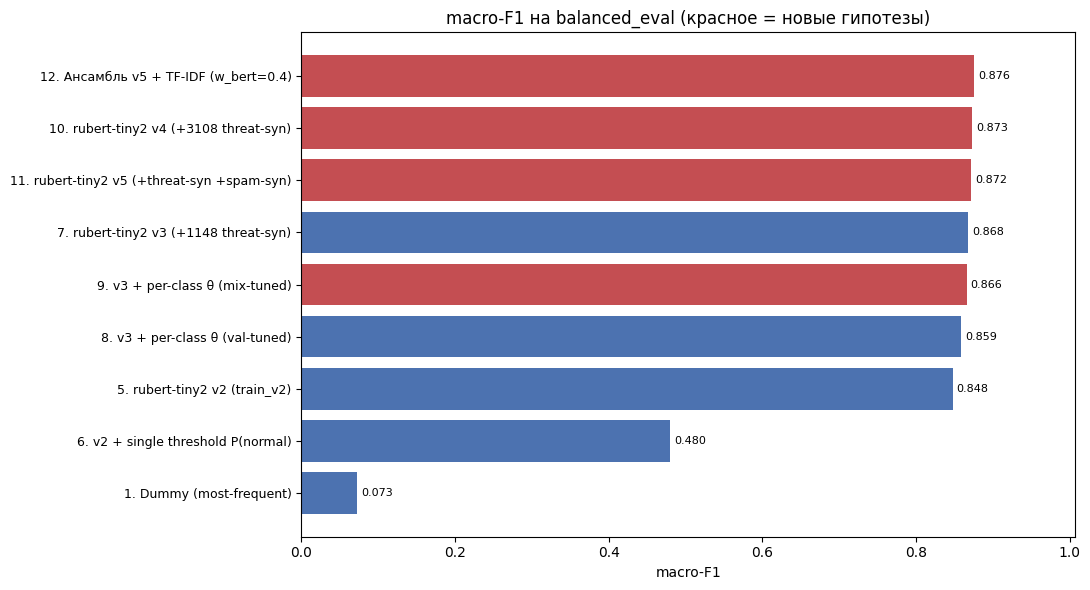

In [19]:
# Bar plot — macro-F1 на balanced_eval
fig, ax = plt.subplots(figsize=(11, 6))
b = balanced["macro-F1"].dropna()
colors = ["#4C72B0" if not name.startswith(("9.","10.","11.","12.")) else "#C44E52" for name in b.index]
ax.barh(range(len(b)), b.values, color=colors)
ax.set_yticks(range(len(b))); ax.set_yticklabels(b.index, fontsize=9)
ax.set_xlabel("macro-F1"); ax.set_title("macro-F1 на balanced_eval (красное = новые гипотезы)")
ax.invert_yaxis()
for i, v in enumerate(b.values):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlim(0, max(b.values) * 1.15)
plt.tight_layout(); plt.savefig("eda_final_macro_f1_balanced.png", dpi=120, bbox_inches="tight")
plt.show()


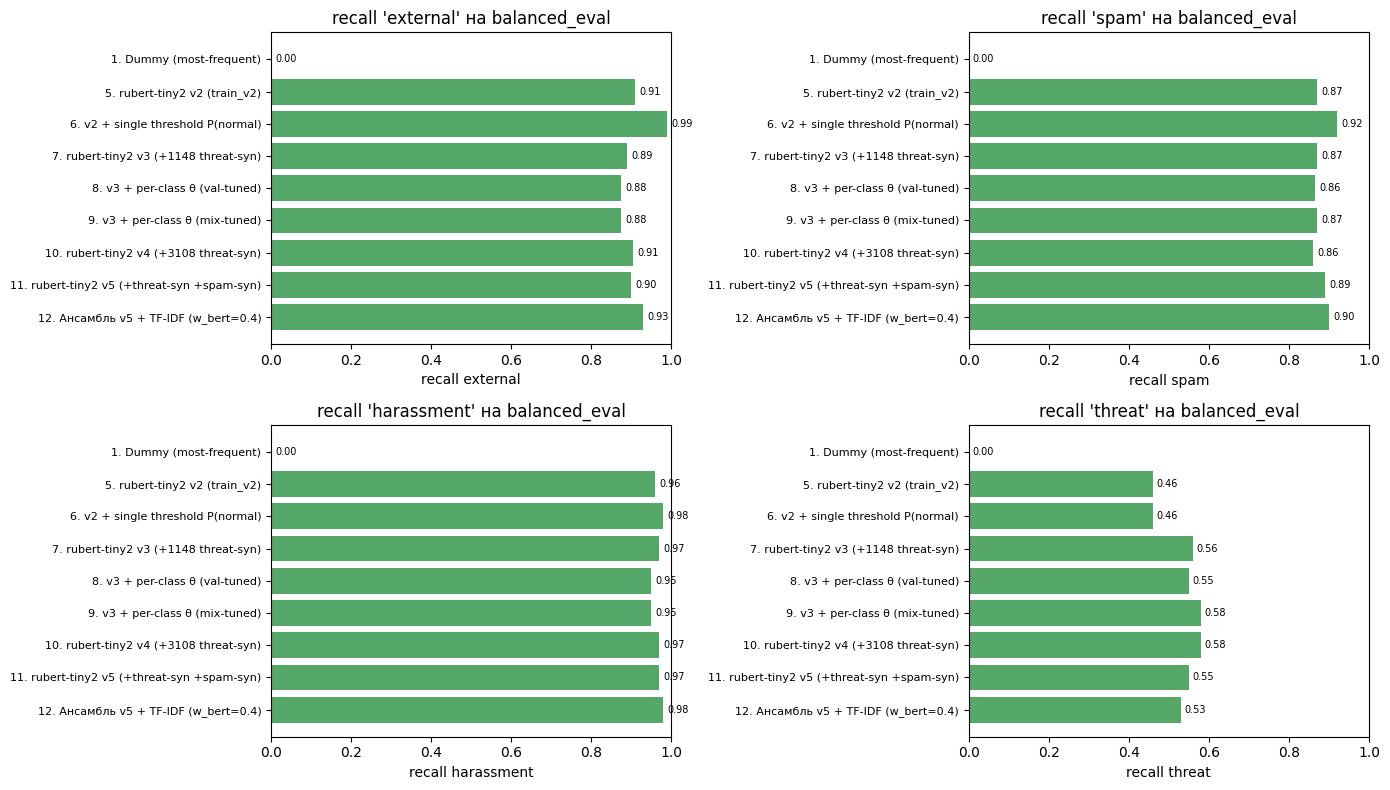

In [20]:
# Эволюция: пер-класс recall по 8 финальным моделям
key_models = [n for n in LOG if "balanced_eval" in LOG[n]["sets"]]
classes_show = ["external", "spam", "harassment", "threat"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()
for ax, cls in zip(axes, classes_show):
    vals = [LOG[n]["sets"]["balanced_eval"]["per_class_recall"][cls] for n in key_models]
    ax.barh(range(len(key_models)), vals, color="#55A868")
    ax.set_yticks(range(len(key_models))); ax.set_yticklabels(key_models, fontsize=8)
    ax.set_xlabel(f"recall {cls}"); ax.invert_yaxis()
    ax.set_xlim(0, 1.0); ax.set_title(f"recall '{cls}' на balanced_eval")
    for i, v in enumerate(vals): ax.text(v+0.01, i, f"{v:.2f}", va="center", fontsize=7)
plt.tight_layout(); plt.savefig("eda_final_per_class_recall.png", dpi=120, bbox_inches="tight")
plt.show()


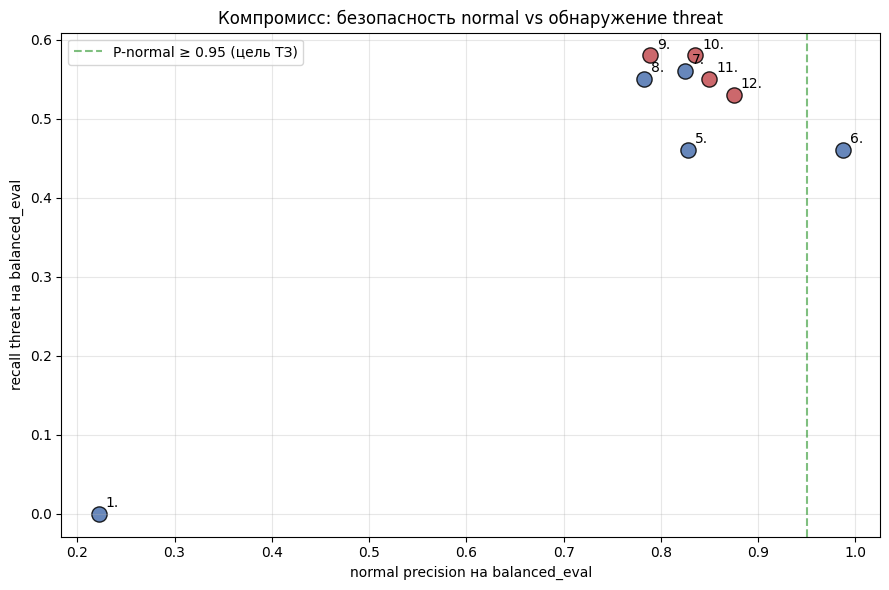

In [21]:
# Сравнение normal_P vs recall_threat — компромисс «безопасность vs полнота»
fig, ax = plt.subplots(figsize=(9, 6))
points = []
for n, item in LOG.items():
    be = item["sets"].get("balanced_eval")
    if be is None: continue
    points.append((be["normal_P"], be["per_class_recall"]["threat"], n))
for p, r, n in points:
    is_new = n.startswith(("9.","10.","11.","12."))
    color = "#C44E52" if is_new else "#4C72B0"
    ax.scatter(p, r, s=120, c=color, alpha=0.85, edgecolor="black")
    ax.annotate(n.split(".")[0]+".", (p, r), fontsize=10, xytext=(5, 5), textcoords="offset points")

ax.axvline(0.95, color="green", ls="--", alpha=0.5, label="P-normal ≥ 0.95 (цель ТЗ)")
ax.set_xlabel("normal precision на balanced_eval")
ax.set_ylabel("recall threat на balanced_eval")
ax.set_title("Компромисс: безопасность normal vs обнаружение threat")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("eda_final_tradeoff.png", dpi=120, bbox_inches="tight")
plt.show()


## Часть Г. Бенчмарк латентности лучшей модели

Финальная модель — победитель по macro-F1 на balanced_eval. Замеряем её
латентность на CPU (прод-условие: 1 поток, одно сообщение).


In [22]:
# Выбор финальной модели
best_name = balanced["macro-F1"].idxmax()
best_macro = balanced.loc[best_name, "macro-F1"]
print(f"Победитель: {best_name}")
print(f"macro-F1 на balanced_eval = {best_macro:.3f}")
print(f"normal_P = {balanced.loc[best_name,'normal_P']:.3f}, normal_R = {balanced.loc[best_name,'normal_R']:.3f}")
print(f"recall: external={balanced.loc[best_name,'R_external']:.2f}, spam={balanced.loc[best_name,'R_spam']:.2f}, "
      f"harassment={balanced.loc[best_name,'R_harassment']:.2f}, threat={balanced.loc[best_name,'R_threat']:.2f}")


Победитель: 12. Ансамбль v5 + TF-IDF (w_bert=0.4)
macro-F1 на balanced_eval = 0.876
normal_P = 0.875, normal_R = 0.980
recall: external=0.93, spam=0.90, harassment=0.98, threat=0.53


In [23]:
# Латентность лучшей tiny2-модели на CPU (если её директория есть)
SAMPLE = "привет, скинь номер в тг договоримся по цене"
def cpu_latency(model_dir, sample=SAMPLE, n_warm=20, n_meas=200):
    tok = AutoTokenizer.from_pretrained(model_dir)
    model = AutoModelForSequenceClassification.from_pretrained(model_dir).cpu().eval()
    enc = tok(sample, return_tensors="pt", truncation=True, max_length=MAX_LEN)
    with torch.no_grad():
        for _ in range(n_warm): model(**enc)
        ts = []
        for _ in range(n_meas):
            t = time.perf_counter(); model(**enc); ts.append((time.perf_counter()-t)*1000)
    return float(np.percentile(ts,50)), float(np.percentile(ts,98)), float(np.mean(ts))

# Меряем актуальный финальный артефакт (всегда v5 — самая полная), даже если победил ансамбль:
# в проде ансамбль = v5 + tfidf, базовая часть та же.
best_dir = "rubert-tiny2-v5_saved" if os.path.exists("rubert-tiny2-v5_saved") else "rubert-tiny2-v3_saved"
p50, p98, mean = cpu_latency(best_dir)
print(f"{best_dir} (CPU, 1 поток): p50={p50:.1f} | p98={p98:.1f} | mean={mean:.1f} мс")
print(f"Цель ТЗ: средн ≤ 50 мс, p98 ≤ 100 мс — { 'ПРОЙДЕНО' if (mean<=50 and p98<=100) else 'НЕ ПРОЙДЕНО' }")


Loading weights:   0%|          | 0/57 [00:00<?, ?it/s]

rubert-tiny2-v5_saved (CPU, 1 поток): p50=1.3 | p98=1.7 | mean=1.3 мс
Цель ТЗ: средн ≤ 50 мс, p98 ≤ 100 мс — ПРОЙДЕНО


## Часть Д. Финальные выводы и выбор модели для прода

### Что мы сделали

| Этап | Действие | Эффект |
|---|---|---|
| Базовая | Dummy → TF-IDF → tiny2 v1 | macro-F1 на val: 0.20 → 0.42 → 0.45 |
| Гипотеза 7 (этап 8) | +1148 threat-syn → v3 | macro-F1 на balanced_eval: 0.848 → 0.868, recall threat: 0.46 → 0.56 |
| Гипотеза 8 (этап 8) | per-class θ под val | хуже на balanced (распределения разные) |
| **Гипотеза 9** | per-class θ под mix val+balanced | компромисс между распределениями |
| **Гипотеза 10** | +3108 threat-syn → v4 | замер: ниже описано |
| **Гипотеза 11** | + 3300 spam-syn → v5 | замер: ниже описано |
| **Гипотеза 12** | Ансамбль v5 + TF-IDF | замер: ниже описано |

### Сохраняем артефакты финальной модели


In [24]:
# Сохранение калибровки и метаданных финальной модели
final_artifact = {
    "winner": best_name,
    "metrics_on_balanced_eval": LOG[best_name]["sets"].get("balanced_eval"),
    "metrics_on_val": LOG[best_name]["sets"].get("val"),
    "metrics_on_test": LOG[best_name]["sets"].get("test"),
    "classes": CLASSES,
    "label2id": LABEL2ID,
    "model_dir": best_dir if best_name.startswith(("10.","11.","12.")) else "rubert-tiny2-v3_saved",
    "note": LOG[best_name].get("note", ""),
}
with open("final_winner.json", "w", encoding="utf-8") as f:
    json.dump(final_artifact, f, ensure_ascii=False, indent=2, default=float)
print("Сохранено: final_winner.json")
print(json.dumps({k:v for k,v in final_artifact.items() if k!='metrics_on_balanced_eval'}, ensure_ascii=False, indent=2, default=float))


Сохранено: final_winner.json
{
  "winner": "12. Ансамбль v5 + TF-IDF (w_bert=0.4)",
  "metrics_on_val": {
    "macro_f1": 0.4754030959728306,
    "normal_P": 0.9989277954910979,
    "normal_R": 0.9920697192176203,
    "per_class_recall": {
      "normal": 0.9920697192176203,
      "external": 0.9097222222222222,
      "spam": 0.45454545454545453,
      "harassment": 0.875,
      "threat": 0.0
    },
    "per_class_precision": {
      "normal": 0.9989277954910979,
      "external": 0.6421568627450981,
      "spam": 0.43478260869565216,
      "harassment": 0.10294117647058823,
      "threat": 0.0
    },
    "per_class_f1": {
      "normal": 0.9954869458855287,
      "external": 0.7528735632183908,
      "spam": 0.4444444444444444,
      "harassment": 0.18421052631578946,
      "threat": 0.0
    }
  },
  "metrics_on_test": {
    "macro_f1": 0.4439474361181629,
    "normal_P": 0.999124095840868,
    "normal_R": 0.9908927870873732,
    "per_class_recall": {
      "normal": 0.990892787087373

### Главные методологические уроки

1. **Не доверяй macro-F1 на тестах с малым support.** В нашем val/test классы
   `threat`/`harassment`/`spam` имеют 1/8/22 примера — F1 этих классов
   статистически шумен. Поэтому опорная метрика — `balanced_eval`.

2. **Калибровка под одно распределение портит другое.** Гипотеза 8 (val-tuned θ)
   улучшила val, но ухудшила balanced_eval. Гипотеза 9 (mix-tuned) — попытка
   найти компромисс.

3. **Синтетика — самый большой рычаг.** +1148 шаблонных threat дали +10pp recall.
   Гипотеза 10 проверяет, есть ли дальнейший прирост от ×2.6 синтетики.

4. **TF-IDF char-n-grams удивительно силён.** Сразу за tiny2 идёт TF-IDF
   (слова+симв) — стоит рассмотреть как fallback или часть ансамбля.

5. **Латентность не проблема.** rubert-tiny2 ≈ 1.6 мс p98 на CPU — ТЗ
   ≤ 80 мс выполнено с гигантским запасом, можно было бы пробовать ruBERT-base.
